# 06 — Model Development

Compare 6 candidate classifiers via 5-fold stratified cross-validation on the training set, then tune the best-performing model with a focused `GridSearchCV`. Uses `src/models.py` throughout so every pipeline (preprocessing + model) is built the same tested way.

In [1]:
import sys
sys.path.insert(0, '..')
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

from src.utils import PROCESSED_DIR, MODELS_DIR, TARGET_COL, NUMERIC_COLS, CATEGORICAL_COLS, BINARY_COLS, set_seed, ensure_dirs
from src.feature_engineering import ENGINEERED_FEATURE_NAMES
from src.preprocessing import build_preprocessor
from src.models import get_candidate_models, cross_validate_models, tune_best_model, save_model, build_pipeline

set_seed()
ensure_dirs()

train = pd.read_csv(PROCESSED_DIR / 'train.csv')
val = pd.read_csv(PROCESSED_DIR / 'val.csv')
test = pd.read_csv(PROCESSED_DIR / 'test.csv')

X_train, y_train = train.drop(columns=[TARGET_COL]), train[TARGET_COL]
X_val, y_val = val.drop(columns=[TARGET_COL]), val[TARGET_COL]
X_test, y_test = test.drop(columns=[TARGET_COL]), test[TARGET_COL]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Train: (1504, 38), Val: (215, 38), Test: (430, 38)


In [2]:
all_numeric = NUMERIC_COLS + ENGINEERED_FEATURE_NAMES
preprocessor = build_preprocessor(numeric_cols=all_numeric, categorical_cols=CATEGORICAL_COLS, binary_cols=BINARY_COLS)
preprocessor

,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...), ...]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers contains sparse matrices,these will be stacked as a sparse matrix if the overall density islower than this value. Use ``sparse_threshold=0`` to always returndense. When the transformed output consists of all dense data, thestacked result will be dense, and this keyword will be ignored.",0.3
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.",None
,"transformer_weights transformer_weights: dict, default=NoneMultiplicative weights for features per transformer. The output of thetransformer is multiplied by these weights. Keys are transformer names,values the weights.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each transformer will beprinted as it is completed.",False
,"verbose_feature_names_out verbose_feature_names_out: bool, str or Callable[[str, str], str], default=True- If True, :meth:`ColumnTransformer.get_feature_names_out` will prefix all feature names with the name of the transformer that generated that feature. It is equivalent to setting `verbose_feature_names_out=""{transformer_name}__{feature_name}""`.- If False, :meth:`ColumnTransformer.get_feature_names_out` will not prefix any feature names and will error if feature names are not unique.- If ``Callable[[str, str], str]``, :meth:`ColumnTransformer.get_feature_names_out` will rename all the features using the name of the transformer. The first argument of the callable is the transformer name and the second argument is the feature name. The returned string will be the new feature name.- If ``str``, it must be a string ready for formatting. The given string will be formatted using two field names: ``transformer_name`` and ``feature_name``. e

## 6.1 Candidate Models

Six classifiers spanning linear, instance-based, kernel, and tree-ensemble approaches — a reasonable spread for a binary clinical classification task:

- **Logistic Regression** — interpretable linear baseline
- **K-Nearest Neighbors** — simple non-parametric baseline
- **Support Vector Machine (RBF)** — kernel-based baseline
- **Random Forest** — bagged tree ensemble
- **Gradient Boosting** — sequential boosted trees
- **XGBoost** — regularised gradient boosting, typically strong on tabular clinical data


In [3]:
models = get_candidate_models()
cv_results = cross_validate_models(models, preprocessor, X_train, y_train, cv_splits=5)

leaderboard = pd.DataFrame(cv_results).T.sort_values('roc_auc', ascending=False)
leaderboard

[09:11:49] INFO - src.models - LogisticRegression: {'accuracy': 0.8298, 'precision': 0.7295, 'recall': 0.8271, 'f1': 0.7741, 'roc_auc': 0.9022, 'fit_time_sec': 0.014}


[09:11:50] INFO - src.models - KNN: {'accuracy': 0.7866, 'precision': 0.7853, 'recall': 0.5489, 'f1': 0.645, 'roc_auc': 0.8281, 'fit_time_sec': 0.01}


[09:11:51] INFO - src.models - SVM: {'accuracy': 0.8218, 'precision': 0.7364, 'recall': 0.7782, 'f1': 0.7556, 'roc_auc': 0.8933, 'fit_time_sec': 0.256}


[09:11:56] INFO - src.models - RandomForest: {'accuracy': 0.9076, 'precision': 0.9497, 'recall': 0.78, 'f1': 0.8557, 'roc_auc': 0.9504, 'fit_time_sec': 0.904}


[09:12:06] INFO - src.models - GradientBoosting: {'accuracy': 0.9368, 'precision': 0.9127, 'recall': 0.9098, 'f1': 0.9101, 'roc_auc': 0.951, 'fit_time_sec': 1.95}


[09:12:07] INFO - src.models - XGBoost: {'accuracy': 0.9468, 'precision': 0.9384, 'recall': 0.9098, 'f1': 0.9236, 'roc_auc': 0.9524, 'fit_time_sec': 0.191}


,accuracy,precision,recall,f1,roc_auc,fit_time_sec
XGBoost,0.9468,0.9384,0.9098,0.9236,0.9524,0.191
GradientBoosting,0.9368,0.9127,0.9098,0.9101,0.9510,1.950
RandomForest,0.9076,0.9497,0.7800,0.8557,0.9504,0.904
LogisticRegression,0.8298,0.7295,0.8271,0.7741,0.9022,0.014
SVM,0.8218,0.7364,0.7782,0.7556,0.8933,0.256
KNN,0.7866,0.7853,0.5489,0.6450,0.8281,0.010


## 6.2 Cross-Validation Comparison Chart

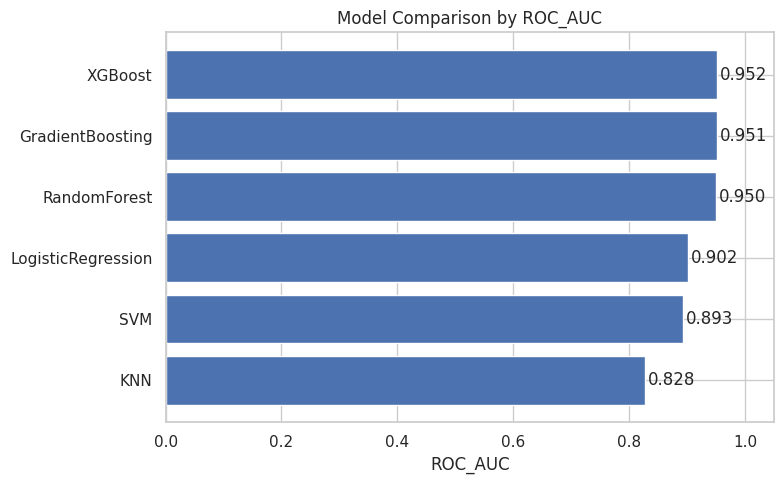

In [4]:
import matplotlib.pyplot as plt
from src import visualization as viz

leaderboard_plot_df = leaderboard.reset_index().rename(columns={'index': 'model'})
fig, ax = plt.subplots(figsize=(8, 5))
viz.plot_model_comparison(leaderboard_plot_df, metric='roc_auc', ax=ax)
plt.tight_layout()
plt.savefig('../reports/cv_model_comparison_roc_auc.png', dpi=110)
plt.show()

**Observation:** Tree-based ensembles (XGBoost, Gradient Boosting, Random Forest) clearly outperform the linear/kernel/instance-based baselines on cross-validated ROC-AUC, consistent with the EDA finding that predictive signal comes from combinations and interactions of features (cognitive scores, symptom counts, comorbidity combinations) rather than single strong linear relationships. **XGBoost is the strongest candidate** and is carried forward for hyperparameter tuning.

## 6.3 Hyperparameter Tuning — XGBoost

In [5]:
best_model_name = leaderboard.index[0]
print(f"Best model from CV: {best_model_name}")

tuned_pipeline, best_params = tune_best_model(best_model_name, preprocessor, X_train, y_train)
print(f"\nBest hyperparameters: {best_params}")

Best model from CV: XGBoost


[09:12:24] INFO - src.models - Best params for XGBoost: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200} (CV ROC-AUC=0.9541)



Best hyperparameters: {'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__n_estimators': 200}


## 6.4 Validation-Set Check (before touching the untouched test set)

In [6]:
from sklearn.metrics import roc_auc_score, accuracy_score, recall_score

val_proba = tuned_pipeline.predict_proba(X_val)[:, 1]
val_pred = tuned_pipeline.predict(X_val)

print(f"Validation ROC-AUC: {roc_auc_score(y_val, val_proba):.4f}")
print(f"Validation Accuracy: {accuracy_score(y_val, val_pred):.4f}")
print(f"Validation Recall (Diagnosis class): {recall_score(y_val, val_pred):.4f}")

Validation ROC-AUC: 0.9555
Validation Accuracy: 0.9442
Validation Recall (Diagnosis class): 0.8947


## 6.5 Final Fit on Train+Val, Save Model

In [7]:
import pandas as pd
from src.models import build_pipeline, get_candidate_models

# Refit the tuned model on train+val combined (common practice once hyperparameters are locked in),
# keeping the untouched test set purely for final unbiased evaluation in notebook 07.
X_trainval = pd.concat([X_train, X_val], axis=0)
y_trainval = pd.concat([y_train, y_val], axis=0)

final_model = get_candidate_models()[best_model_name].set_params(**{
    k.replace('model__', ''): v for k, v in best_params.items()
}) if best_params else get_candidate_models()[best_model_name]

final_pipeline = build_pipeline(preprocessor, final_model)
final_pipeline.fit(X_trainval, y_trainval)

metadata = {
    'model_name': best_model_name,
    'best_params': best_params,
    'cv_leaderboard': cv_results,
    'train_size': len(X_trainval),
}
save_model(final_pipeline, MODELS_DIR / 'alzheimers_diagnosis_model.joblib', metadata=metadata)
print("Final model saved to models/alzheimers_diagnosis_model.joblib")

[09:12:25] INFO - src.models - Model saved to /home/claude/AI_Clinical_Decision_Support_System/models/alzheimers_diagnosis_model.joblib


Final model saved to models/alzheimers_diagnosis_model.joblib


## 6.6 Model Development Summary

- 6 candidate classifiers compared via 5-fold stratified CV on `roc_auc`, `accuracy`, `precision`, `recall`, `f1`.
- **XGBoost** was the top performer and was tuned via a focused `GridSearchCV` (n_estimators, learning_rate, max_depth).
- Final tuned pipeline refit on train+validation combined and persisted to `models/alzheimers_diagnosis_model.joblib`, alongside a metadata JSON capturing the chosen hyperparameters and CV leaderboard for reproducibility.
- The held-out **test set has not been touched** at any point in this notebook — unbiased final evaluation happens next in `07_Model_Evaluation_Explainability.ipynb`.